# ETH Price Analysis: Halvings, Upgrades & Macro Events

**Data:** `analytics.market_variables_history` — daily 5 PM NY close  
**Range:** 2016-05-18 → present (~10 years)

In [1]:
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from sqlalchemy import text

warnings.filterwarnings('ignore')

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dotenv import load_dotenv
load_dotenv(project_root / '.env')
from etl.common.db.postgres import get_engine

engine = get_engine()

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.5,
    'font.size':        9,
})

In [2]:
with engine.connect() as conn:
    df = pd.read_sql(
        text("""
            SELECT date_day, eth_close_usd
            FROM analytics.market_variables_history
            WHERE eth_close_usd IS NOT NULL
            ORDER BY date_day
        """),
        conn,
    )

df['date_day'] = pd.to_datetime(df['date_day'])
df = df.set_index('date_day')

print(f"ETH data: {df.index.min().date()} → {df.index.max().date()}  ({len(df):,} rows)")
print(f"Price range: ${df['eth_close_usd'].min():.2f} – ${df['eth_close_usd'].max():,.2f}")
print(f"ATH date: {df['eth_close_usd'].idxmax().date()}  @ ${df['eth_close_usd'].max():,.2f}")

ETH data: 2016-05-18 → 2026-04-27  (3,623 rows)
Price range: $6.73 – $4,849.51
ATH date: 2025-08-22  @ $4,849.51


In [3]:
# ── Event definitions ─────────────────────────────────────────────────────────

# Bitcoin block reward halvings
BTC_HALVINGS = [
    ('2016-07-09', 'Halving #2\n(12.5 BTC)'),
    ('2020-05-11', 'Halving #3\n(6.25 BTC)'),
    ('2024-04-20', 'Halving #4\n(3.125 BTC)'),
]

# Ethereum network upgrades
ETH_UPGRADES = [
    ('2016-03-14', 'Homestead'),
    ('2017-10-16', 'Byzantium'),
    ('2019-02-28', 'Constantinople'),
    ('2019-12-08', 'Istanbul'),
    ('2021-04-15', 'Berlin'),
    ('2021-08-05', 'London\n(EIP-1559)'),
    ('2022-09-15', 'The Merge\n(→ PoS)'),
    ('2023-04-12', 'Shanghai\n(withdrawals)'),
    ('2024-03-13', 'Dencun\n(EIP-4844)'),
    ('2025-05-07', 'Pectra'),
]

# Political, regulatory, and macro events
# Negative events (red): LUNA, 3AC/Celsius, FTX, SEC actions
# Positive/neutral events (green): ETF approvals, Trump win, GENIUS Act
MACRO_NEG = [
    ('2022-05-09', 'LUNA/UST\nCollapse'),
    ('2022-06-13', 'Celsius/3AC\nCrisis'),
    ('2022-11-11', 'FTX\nCollapse'),
    ('2023-06-05', 'SEC v. Binance\n& Coinbase'),
]

MACRO_POS = [
    ('2021-09-07', 'El Salvador\nBTC legal tender'),
    ('2024-01-10', 'Spot BTC\nETF live'),
    ('2024-07-23', 'Spot ETH\nETF live'),
    ('2024-11-05', 'Trump\nElected'),
    ('2025-01-20', 'Trump\nInauguration'),
    ('2025-03-06', 'BTC Strategic\nReserve EO'),
    ('2025-03-07', 'WH Crypto\nSummit'),
    ('2025-08-01', 'GENIUS Act\n(~signed)'),  # approximate — verify date
]

# Color palette
C_HALVING  = '#F7931A'   # BTC orange
C_ETH      = '#8247E5'   # ETH purple
C_NEG      = '#F85149'   # red — bear events
C_POS      = '#3FB950'   # green — bull/regulatory wins
C_PRICE    = '#58A6FF'   # blue — price line

print(f'Events loaded: {len(BTC_HALVINGS)} halvings, {len(ETH_UPGRADES)} ETH upgrades, '
      f'{len(MACRO_NEG)} neg macro, {len(MACRO_POS)} pos macro')

Events loaded: 3 halvings, 10 ETH upgrades, 4 neg macro, 8 pos macro


In [4]:
# ── Helper: draw annotated event lines ────────────────────────────────────────

def add_events(ax, events, color, offsets, log_scale=True):
    """Draw vertical rules with staggered labels. offsets is a list of
    fractions [0..1] in log-space (or linear-space) for label placement."""
    ylo, yhi = ax.get_ylim()

    for i, (date_str, label) in enumerate(events):
        dt = pd.Timestamp(date_str)
        if dt < df.index.min() or dt > df.index.max() + pd.Timedelta(days=90):
            continue

        frac = offsets[i % len(offsets)]
        if log_scale:
            y_txt = ylo * (yhi / ylo) ** frac
        else:
            y_txt = ylo + frac * (yhi - ylo)

        ax.axvline(dt, color=color, alpha=0.45, linewidth=0.9, linestyle='--', zorder=2)
        ax.text(
            dt, y_txt, label,
            fontsize=6.2, color=color, rotation=90,
            ha='right', va='center', zorder=5,
            bbox=dict(boxstyle='round,pad=0.15', facecolor='#0d1117',
                      alpha=0.85, edgecolor=color, linewidth=0.5),
        )


print('Helper defined.')

Helper defined.


## Chart 1 — Full History (2016 – Present, log scale)

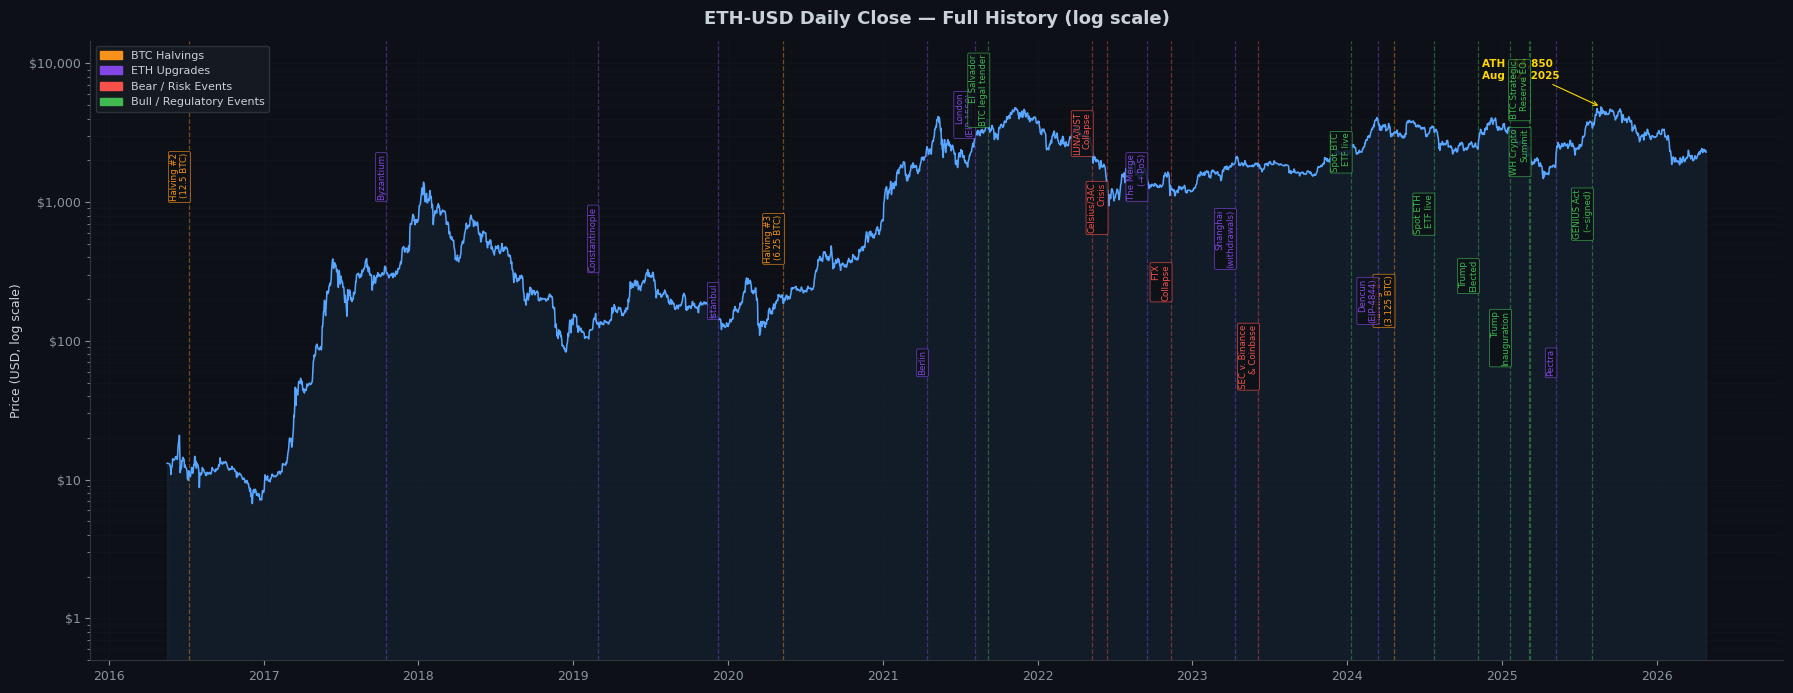

In [5]:
fig, ax = plt.subplots(figsize=(18, 7))

# Price line
ax.semilogy(df.index, df['eth_close_usd'], color=C_PRICE, linewidth=1.1, zorder=3)
ax.fill_between(df.index, df['eth_close_usd'], 1e-1, alpha=0.08, color=C_PRICE)

ax.set_ylim(0.5, df['eth_close_usd'].max() * 3)

# Events — offsets cycle through label heights in log space
add_events(ax, BTC_HALVINGS,  C_HALVING, [0.78, 0.68, 0.58], log_scale=True)
add_events(ax, ETH_UPGRADES,  C_ETH,     [0.88, 0.78, 0.68, 0.58, 0.48], log_scale=True)
add_events(ax, MACRO_NEG,     C_NEG,     [0.85, 0.73, 0.61, 0.49], log_scale=True)
add_events(ax, MACRO_POS,     C_POS,     [0.92, 0.82, 0.72, 0.62, 0.52], log_scale=True)

# ATH annotation
ath_date = df['eth_close_usd'].idxmax()
ath_val  = df['eth_close_usd'].max()
ax.annotate(
    f'ATH  ${ath_val:,.0f}\n{ath_date.strftime("%b %d, %Y")}',
    xy=(ath_date, ath_val),
    xytext=(ath_date - pd.Timedelta(days=280), ath_val * 1.6),
    fontsize=7.5, color='#FFD700', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#FFD700', lw=0.8),
)

# Axes
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, which='both', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('ETH-USD Daily Close — Full History (log scale)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Price (USD, log scale)')

# Legend
legend_handles = [
    mpatches.Patch(color=C_HALVING, label='BTC Halvings'),
    mpatches.Patch(color=C_ETH,     label='ETH Upgrades'),
    mpatches.Patch(color=C_NEG,     label='Bear / Risk Events'),
    mpatches.Patch(color=C_POS,     label='Bull / Regulatory Events'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=8,
          facecolor='#161b22', edgecolor='#30363d', framealpha=0.9)

plt.tight_layout()
plt.show()

## Chart 2 — Modern Cycle (Jan 2021 – Present, log scale)

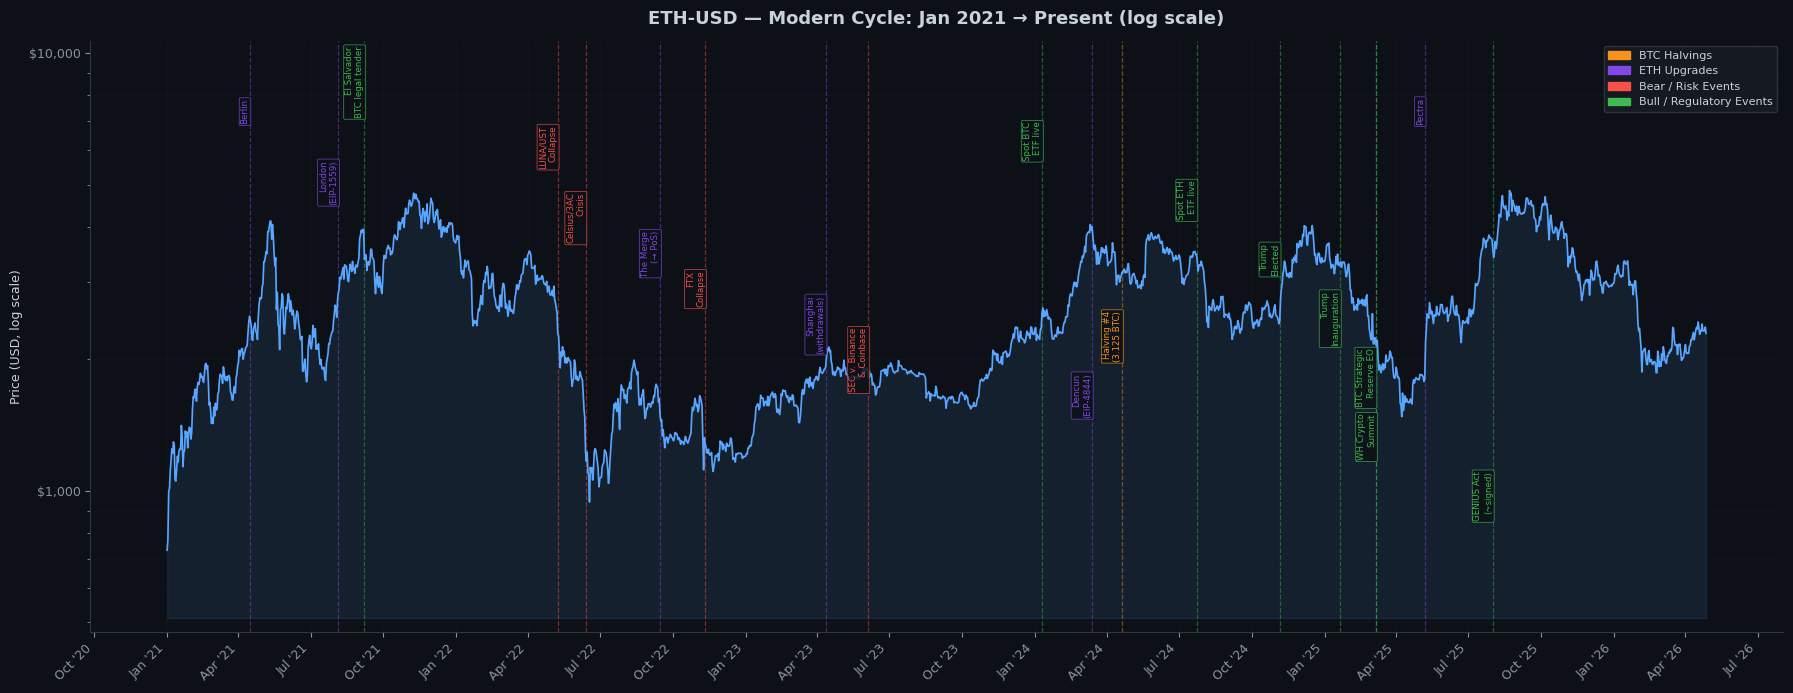

In [6]:
modern = df[df.index >= '2021-01-01'].copy()

fig, ax = plt.subplots(figsize=(18, 7))

ax.semilogy(modern.index, modern['eth_close_usd'], color=C_PRICE, linewidth=1.2, zorder=3)
ax.fill_between(modern.index, modern['eth_close_usd'],
                modern['eth_close_usd'].min() * 0.7, alpha=0.1, color=C_PRICE)

ax.set_ylim(modern['eth_close_usd'].min() * 0.65, modern['eth_close_usd'].max() * 2.2)

# Filter events to 2021+
def post2021(evts):
    return [(d, l) for d, l in evts if pd.Timestamp(d) >= pd.Timestamp('2021-01-01')]

add_events(ax, post2021(BTC_HALVINGS), C_HALVING, [0.50, 0.40], log_scale=True)
add_events(ax, post2021(ETH_UPGRADES), C_ETH,     [0.88, 0.76, 0.64, 0.52, 0.40], log_scale=True)
add_events(ax, MACRO_NEG,             C_NEG,     [0.82, 0.70, 0.58, 0.46], log_scale=True)
add_events(ax, MACRO_POS,             C_POS,     [0.93, 0.83, 0.73, 0.63, 0.53, 0.43, 0.33, 0.23], log_scale=True)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.xticks(rotation=45, ha='right')
ax.grid(True, which='both', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('ETH-USD — Modern Cycle: Jan 2021 → Present (log scale)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Price (USD, log scale)')

legend_handles = [
    mpatches.Patch(color=C_HALVING, label='BTC Halvings'),
    mpatches.Patch(color=C_ETH,     label='ETH Upgrades'),
    mpatches.Patch(color=C_NEG,     label='Bear / Risk Events'),
    mpatches.Patch(color=C_POS,     label='Bull / Regulatory Events'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=8,
          facecolor='#161b22', edgecolor='#30363d', framealpha=0.9)

plt.tight_layout()
plt.show()

## Event Price Table

ETH close price on the event date (or nearest trading day), plus drawdown from ATH at that moment.

In [7]:
all_events = (
    [('BTC Halving',  d, l.replace('\n', ' ')) for d, l in BTC_HALVINGS] +
    [('ETH Upgrade',  d, l.replace('\n', ' ')) for d, l in ETH_UPGRADES] +
    [('Bear Event',   d, l.replace('\n', ' ')) for d, l in MACRO_NEG] +
    [('Bull/Reg',     d, l.replace('\n', ' ')) for d, l in MACRO_POS]
)

ath = df['eth_close_usd'].max()

rows = []
for cat, date_str, label in sorted(all_events, key=lambda x: x[1]):
    dt = pd.Timestamp(date_str)

    # find nearest date in data (within 7 days)
    candidates = df.index[(df.index >= dt - pd.Timedelta(days=3)) &
                           (df.index <= dt + pd.Timedelta(days=3))]
    if len(candidates) == 0:
        price = None
        dd_pct = None
    else:
        nearest = candidates[np.argmin(np.abs(candidates - dt))]
        price   = df.loc[nearest, 'eth_close_usd']
        # drawdown from running ATH at that point in time
        running_ath = df.loc[:nearest, 'eth_close_usd'].max()
        dd_pct = (price - running_ath) / running_ath * 100

    rows.append({'Category': cat, 'Date': date_str, 'Event': label,
                 'ETH Price': price, 'DD from ATH (%)': dd_pct})

tbl = pd.DataFrame(rows)
tbl['ETH Price']      = tbl['ETH Price'].apply(lambda x: f"${x:,.2f}"      if x else 'N/A (future)')
tbl['DD from ATH (%)'] = tbl['DD from ATH (%)'].apply(lambda x: f"{x:.1f}%" if x else '–')

pd.set_option('display.max_colwidth', 40)
pd.set_option('display.max_rows', 50)
tbl

,Category,Date,Event,ETH Price,DD from ATH (%)
0,ETH Upgrade,2016-03-14,Homestead,$nan,nan%
1,BTC Halving,2016-07-09,Halving #2 (12.5 BTC),$11.07,-47.0%
2,ETH Upgrade,2017-10-16,Byzantium,$336.46,-14.0%
3,ETH Upgrade,2019-02-28,Constantinople,$134.68,-90.3%
4,ETH Upgrade,2019-12-08,Istanbul,$151.42,-89.1%
5,BTC Halving,2020-05-11,Halving #3 (6.25 BTC),$185.79,-86.7%
6,ETH Upgrade,2021-04-15,Berlin,"$2,505.00",–
7,ETH Upgrade,2021-08-05,London (EIP-1559),"$2,827.41",-31.5%
8,Bull/Reg,2021-09-07,El Salvador BTC legal tender,"$3,377.29",-18.2%
9,Bear Event,2022-05-09,LUNA/UST Collapse,"$2,275.74",-52.4%


## Halving Cycle Price Summary

ETH price 90 days before and 180 days after each BTC halving.

In [8]:
halving_rows = []
for date_str, label in BTC_HALVINGS:
    dt = pd.Timestamp(date_str)
    label_clean = label.replace('\n', ' ')

    def price_at(d):
        cands = df.index[(df.index >= d - pd.Timedelta(days=2)) &
                          (df.index <= d + pd.Timedelta(days=2))]
        if len(cands) == 0:
            return None
        nearest = cands[np.argmin(np.abs(cands - d))]
        return df.loc[nearest, 'eth_close_usd']

    p_minus90  = price_at(dt - pd.Timedelta(days=90))
    p_halving  = price_at(dt)
    p_plus90   = price_at(dt + pd.Timedelta(days=90))
    p_plus180  = price_at(dt + pd.Timedelta(days=180))
    p_plus365  = price_at(dt + pd.Timedelta(days=365))

    def pct(base, x):
        if base and x:
            return f"{(x/base - 1)*100:+.1f}%"
        return 'N/A'

    halving_rows.append({
        'Halving': label_clean,
        'Date': date_str,
        '−90d price': f"${p_minus90:,.0f}" if p_minus90 else 'N/A',
        'At halving': f"${p_halving:,.0f}" if p_halving else 'N/A',
        '+90d price': f"${p_plus90:,.0f}" if p_plus90 else 'N/A',
        '+90d ret': pct(p_halving, p_plus90),
        '+180d price': f"${p_plus180:,.0f}" if p_plus180 else 'N/A',
        '+180d ret': pct(p_halving, p_plus180),
        '+365d price': f"${p_plus365:,.0f}" if p_plus365 else 'N/A',
        '+365d ret': pct(p_halving, p_plus365),
    })

pd.DataFrame(halving_rows)

,Halving,Date,−90d price,At halving,+90d price,+90d ret,+180d price,+180d ret,+365d price,+365d ret
0,Halving #2 (12.5 BTC),2016-07-09,N/A,$11,$13,+13.8%,$10,-7.0%,$243,+2094.9%
1,Halving #3 (6.25 BTC),2020-05-11,$238,$186,$389,+109.6%,$437,+135.2%,"$4,130",+2122.9%
2,Halving #4 (3.125 BTC),2024-04-20,"$2,461","$3,154","$3,514",+11.4%,"$2,603",-17.5%,"$1,589",-49.6%


## Chart 3 — Indexed Returns from Each Halving (rebased to 100 at halving date)

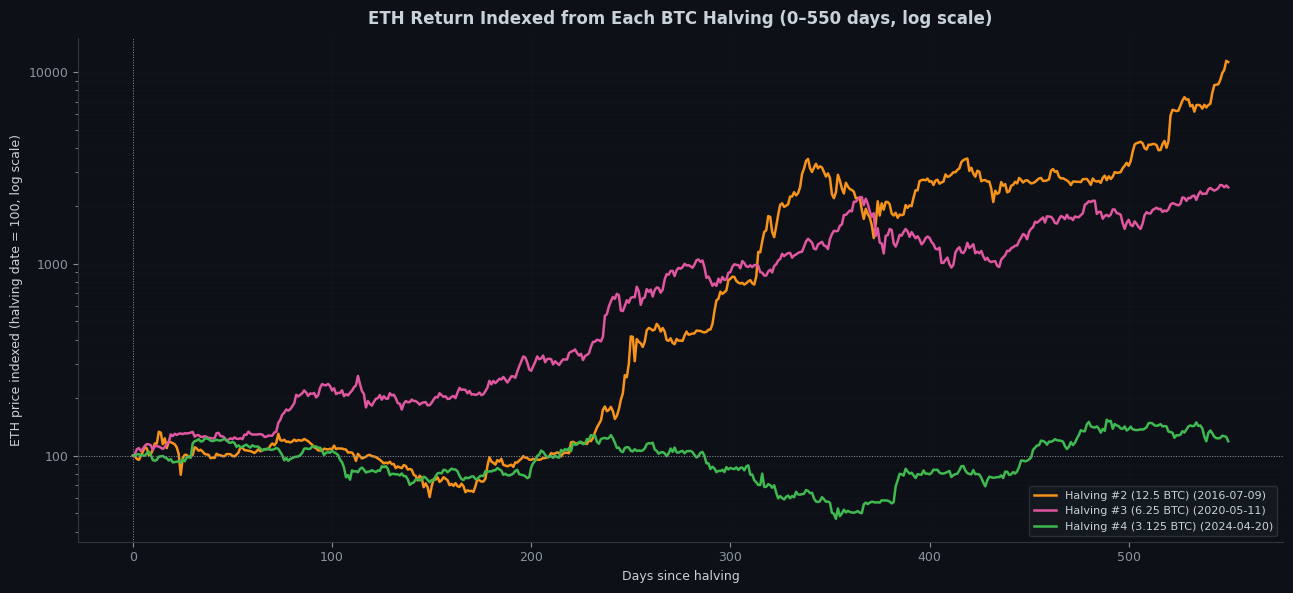

In [9]:
WINDOW_DAYS = 550
halving_colors = ['#F7931A', '#E056A0', '#3FB950']

fig, ax = plt.subplots(figsize=(13, 6))

for (date_str, label), color in zip(BTC_HALVINGS, halving_colors):
    dt = pd.Timestamp(date_str)
    window = df[(df.index >= dt) & (df.index <= dt + pd.Timedelta(days=WINDOW_DAYS))].copy()
    if window.empty:
        continue
    base = window['eth_close_usd'].iloc[0]
    window['indexed'] = window['eth_close_usd'] / base * 100
    window['day'] = (window.index - dt).days
    ax.plot(window['day'], window['indexed'],
            label=f"{label.replace(chr(10), ' ')} ({date_str})",
            color=color, linewidth=1.8)

ax.set_yscale('log')
ax.axhline(100, color='#8b949e', linewidth=0.7, linestyle=':')
ax.axvline(0,   color='#8b949e', linewidth=0.7, linestyle=':')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.set_xlabel('Days since halving')
ax.set_ylabel('ETH price indexed (halving date = 100, log scale)')
ax.set_title('ETH Return Indexed from Each BTC Halving (0–550 days, log scale)', fontsize=12, fontweight='bold', pad=10)
ax.grid(True, which='both', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8, facecolor='#161b22', edgecolor='#30363d')

plt.tight_layout()
plt.show()